# Deep Learning vs Variational Methods: Middlebury Benchmark

Compares deep learning methods (RAFT, SEA-RAFT, WAFT) against the
variational Classic+NL-Fast method on all Middlebury sequences with
ground truth. Evaluates using Average Angular Error (AAE) and
Average Endpoint Error (AEPE).

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time

from flow_fast import estimate_flow, flow_to_color
from flow_fast.evaluation.metrics import flow_angular_error
from flow_fast.io.flo_io import read_flo

%matplotlib inline

## Run All Methods on All Sequences

In [2]:
data_dir = os.path.join('..', 'data')
sequences = ['Dimetrodon', 'Grove2', 'Grove3', 'Hydrangea', 'RubberWhale', 'Urban2', 'Urban3', 'Venus']
methods = ['classic+nl-fast', 'raft', 'sea-raft', 'waft']

results = {}

for seq in sequences:
    print(f'\n=== {seq} ===')
    im1 = np.array(Image.open(os.path.join(data_dir, 'other-data', seq, 'frame10.png'))).astype(float)
    im2 = np.array(Image.open(os.path.join(data_dir, 'other-data', seq, 'frame11.png'))).astype(float)
    gt = read_flo(os.path.join(data_dir, 'other-gt-flow', seq, 'flow10.flo'))
    tu, tv = gt[:, :, 0], gt[:, :, 1]

    results[seq] = {}
    for method in methods:
        t0 = time.time()
        uv = estimate_flow(im1, im2, method=method)
        elapsed = time.time() - t0
        aae, _, aepe = flow_angular_error(tu, tv, uv[:, :, 0], uv[:, :, 1], border=0)
        results[seq][method] = {'aae': aae, 'aepe': aepe, 'time': elapsed, 'flow': uv}
        print(f'  {method:<18} AAE={aae:.3f}  EPE={aepe:.3f}  Time={elapsed:.2f}s')


=== Dimetrodon ===
GNC stage: 1
  Pyramid level: 5
    Iter: 1 1 (delta: 4.259177)
    Iter: 2 1 (delta: 1.088846)
    Iter: 3 1 (delta: 1.034182)
  Pyramid level: 4
    Iter: 1 1 (delta: 5.636057)
    Iter: 2 1 (delta: 3.079107)
    Iter: 3 1 (delta: 3.060421)
  Pyramid level: 3


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    Iter: 1 1 (delta: 16.880529)
    Iter: 2 1 (delta: 11.581959)
    Iter: 3 1 (delta: 11.529589)
  Pyramid level: 2
    Iter: 1 1 (delta: 49.520856)
    Iter: 2 1 (delta: 38.327642)
    Iter: 3 1 (delta: 38.023205)
  Pyramid level: 1
    Iter: 1 1 (delta: 244.346403)
    Iter: 2 1 (delta: 224.958629)
    Iter: 3 1 (delta: 220.916285)
GNC stage 1 finished, 0.06 minutes passed
GNC stage: 2
  Pyramid level: 2
    Iter: 1 1 (delta: 34.906055)
    Iter: 2 1 (delta: 12.737593)
    Iter: 3 1 (delta: 9.372867)
  Pyramid level: 1
    Iter: 1 1 (delta: 14.134161)
    Iter: 2 1 (delta: 14.254723)
    Iter: 3 1 (delta: 13.724489)
GNC stage 2 finished, 0.17 minutes passed
  classic+nl-fast    AAE=2.440  EPE=0.126  Time=10.56s
  raft               AAE=3.910  EPE=0.198  Time=2.21s


xFormers not available
xFormers not available


  sea-raft           AAE=3.311  EPE=0.164  Time=2.27s
  waft               AAE=7.004  EPE=0.370  Time=2.53s

=== Grove2 ===
GNC stage: 1
  Pyramid level: 5
    Iter: 1 1 (delta: 7.576727)
    Iter: 2 1 (delta: 1.297562)
    Iter: 3 1 (delta: 1.182335)
  Pyramid level: 4
    Iter: 1 1 (delta: 7.384896)
    Iter: 2 1 (delta: 5.537372)
    Iter: 3 1 (delta: 5.502062)
  Pyramid level: 3
    Iter: 1 1 (delta: 28.177639)
    Iter: 2 1 (delta: 22.034012)
    Iter: 3 1 (delta: 21.591871)
  Pyramid level: 2
    Iter: 1 1 (delta: 86.806560)
    Iter: 2 1 (delta: 74.915886)
    Iter: 3 1 (delta: 73.964476)
  Pyramid level: 1
    Iter: 1 1 (delta: 257.335017)
    Iter: 2 1 (delta: 235.855992)
    Iter: 3 1 (delta: 233.316110)
GNC stage 1 finished, 0.08 minutes passed
GNC stage: 2
  Pyramid level: 2
    Iter: 1 1 (delta: 46.110559)
    Iter: 2 1 (delta: 23.085114)
    Iter: 3 1 (delta: 18.688358)
  Pyramid level: 1
    Iter: 1 1 (delta: 38.028025)
    Iter: 2 1 (delta: 28.126174)
    Iter: 3 1 (del

## Results Table: Average Angular Error (AAE)

In [3]:
header = f'{"Sequence":<14}' + ''.join(f'{m:>18}' for m in methods)
print(header)
print('-' * len(header))

avg = {m: [] for m in methods}
for seq in sequences:
    row = f'{seq:<14}'
    for m in methods:
        aae = results[seq][m]['aae']
        avg[m].append(aae)
        row += f'{aae:>18.3f}'
    print(row)

print('-' * len(header))
row = f'{"Average":<14}'
for m in methods:
    row += f'{np.mean(avg[m]):>18.3f}'
print(row)

Sequence         classic+nl-fast              raft          sea-raft              waft
--------------------------------------------------------------------------------------
Dimetrodon                 2.440             3.910             3.311             7.004
Grove2                     1.426             3.534             1.952             2.133
Grove3                     4.958             6.801             4.362             3.916
Hydrangea                  1.940             2.720             2.842             2.245
RubberWhale                2.514             6.049             4.009             6.141
Urban2                     1.857             2.952             1.969             1.927
Urban3                     3.114             2.986             2.261             1.450
Venus                      3.331             2.874             3.121             2.912
--------------------------------------------------------------------------------------
Average                    2.698           

## Results Table: Average Endpoint Error (AEPE)

In [4]:
header = f'{"Sequence":<14}' + ''.join(f'{m:>18}' for m in methods)
print(header)
print('-' * len(header))

avg = {m: [] for m in methods}
for seq in sequences:
    row = f'{seq:<14}'
    for m in methods:
        aepe = results[seq][m]['aepe']
        avg[m].append(aepe)
        row += f'{aepe:>18.3f}'
    print(row)

print('-' * len(header))
row = f'{"Average":<14}'
for m in methods:
    row += f'{np.mean(avg[m]):>18.3f}'
print(row)

Sequence         classic+nl-fast              raft          sea-raft              waft
--------------------------------------------------------------------------------------
Dimetrodon                 0.126             0.198             0.164             0.370
Grove2                     0.098             0.246             0.133             0.155
Grove3                     0.472             0.677             0.432             0.378
Hydrangea                  0.158             0.221             0.219             0.190
RubberWhale                0.081             0.185             0.121             0.185
Urban2                     0.191             0.314             0.247             0.174
Urban3                     0.440             0.344             0.256             0.174
Venus                      0.240             0.234             0.248             0.201
--------------------------------------------------------------------------------------
Average                    0.226           

## Bar Charts: AAE and AEPE by Method

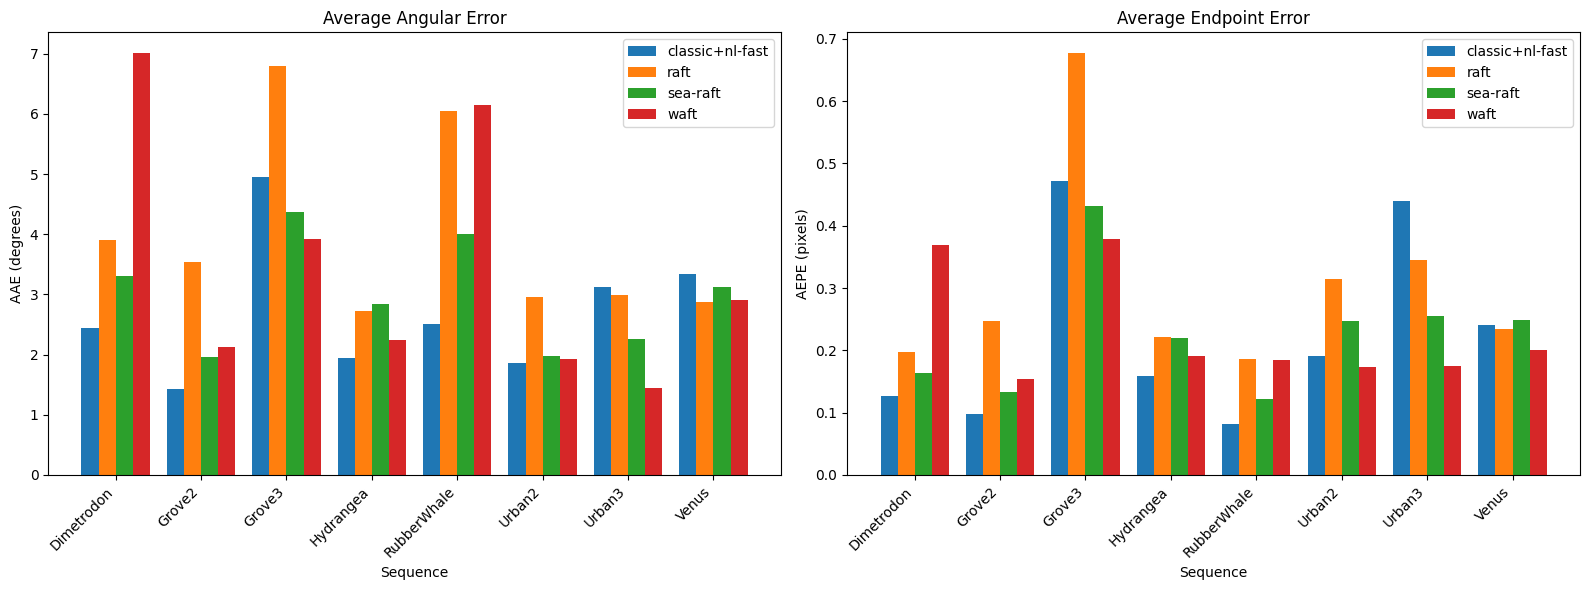

In [5]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(sequences))
width = 0.2

for i, m in enumerate(methods):
    aae_vals = [results[seq][m]['aae'] for seq in sequences]
    axes[0].bar(x + i * width, aae_vals, width, label=m)

axes[0].set_xlabel('Sequence')
axes[0].set_ylabel('AAE (degrees)')
axes[0].set_title('Average Angular Error')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(sequences, rotation=45, ha='right')
axes[0].legend()

for i, m in enumerate(methods):
    aepe_vals = [results[seq][m]['aepe'] for seq in sequences]
    axes[1].bar(x + i * width, aepe_vals, width, label=m)

axes[1].set_xlabel('Sequence')
axes[1].set_ylabel('AEPE (pixels)')
axes[1].set_title('Average Endpoint Error')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(sequences, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

## Timing Comparison

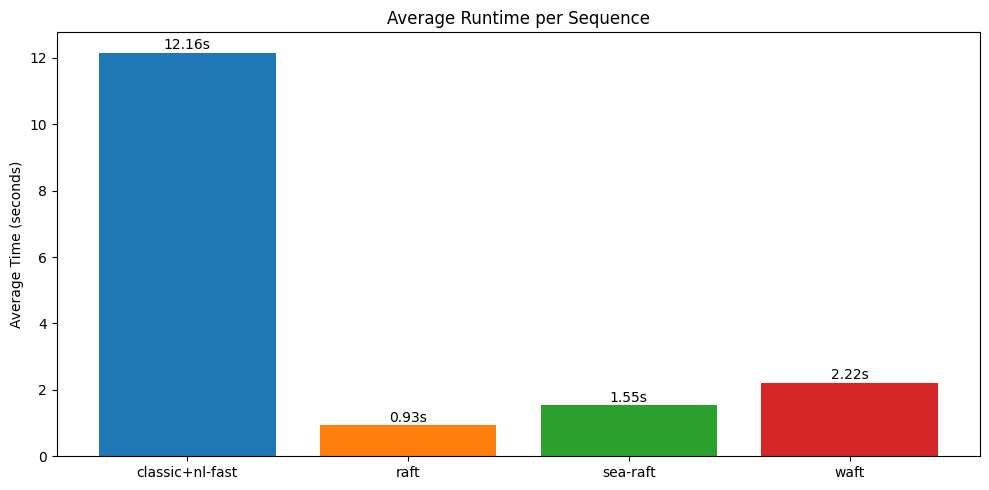

In [6]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 5))

avg_times = [np.mean([results[seq][m]['time'] for seq in sequences]) for m in methods]
bars = ax.bar(methods, avg_times, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_ylabel('Average Time (seconds)')
ax.set_title('Average Runtime per Sequence')

for bar, t in zip(bars, avg_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{t:.2f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Flow Visualization: All Methods on RubberWhale

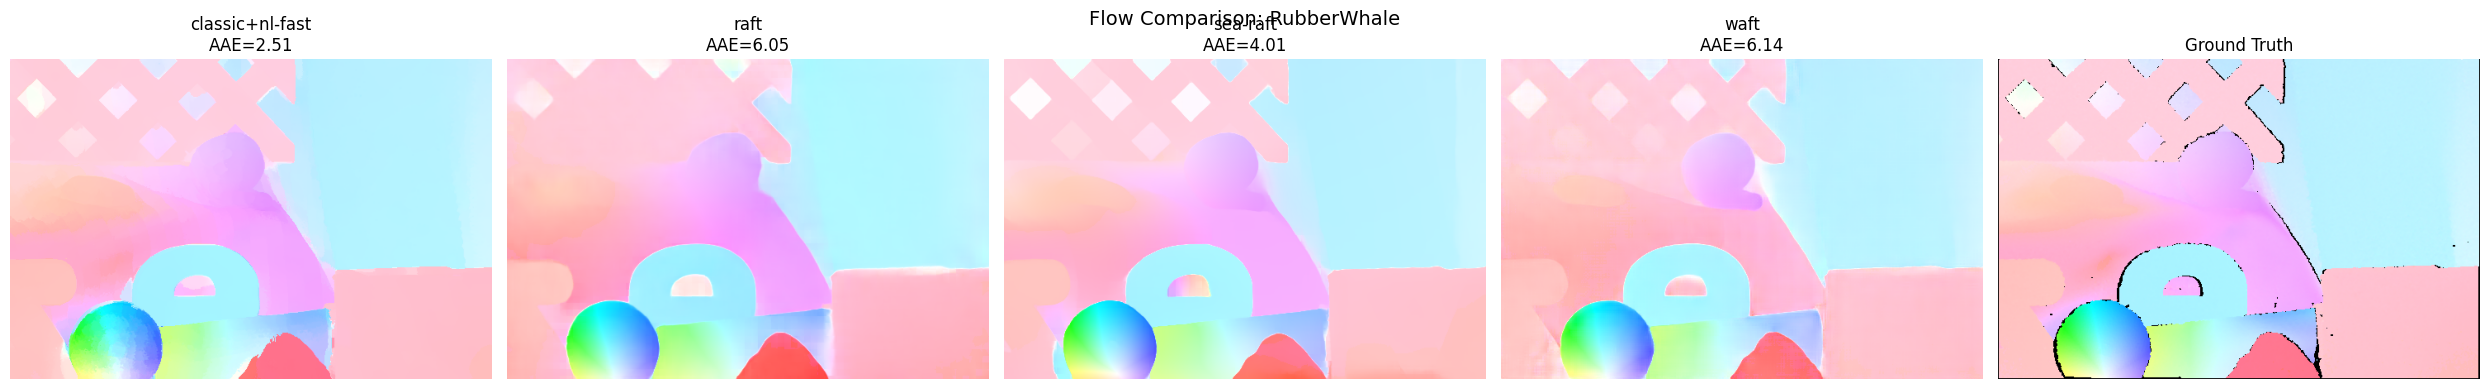

In [7]:
%matplotlib inline

seq = 'RubberWhale'
gt = read_flo(os.path.join(data_dir, 'other-gt-flow', seq, 'flow10.flo'))

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, m in enumerate(methods):
    color_img = flow_to_color(results[seq][m]['flow'])
    axes[i].imshow(color_img)
    aae = results[seq][m]['aae']
    axes[i].set_title(f'{m}\nAAE={aae:.2f}')
    axes[i].axis('off')

color_gt = flow_to_color(gt)
axes[4].imshow(color_gt)
axes[4].set_title('Ground Truth')
axes[4].axis('off')

plt.suptitle(f'Flow Comparison: {seq}', fontsize=14)
plt.tight_layout()
plt.show()

## Flow Visualization: All Methods on Urban2

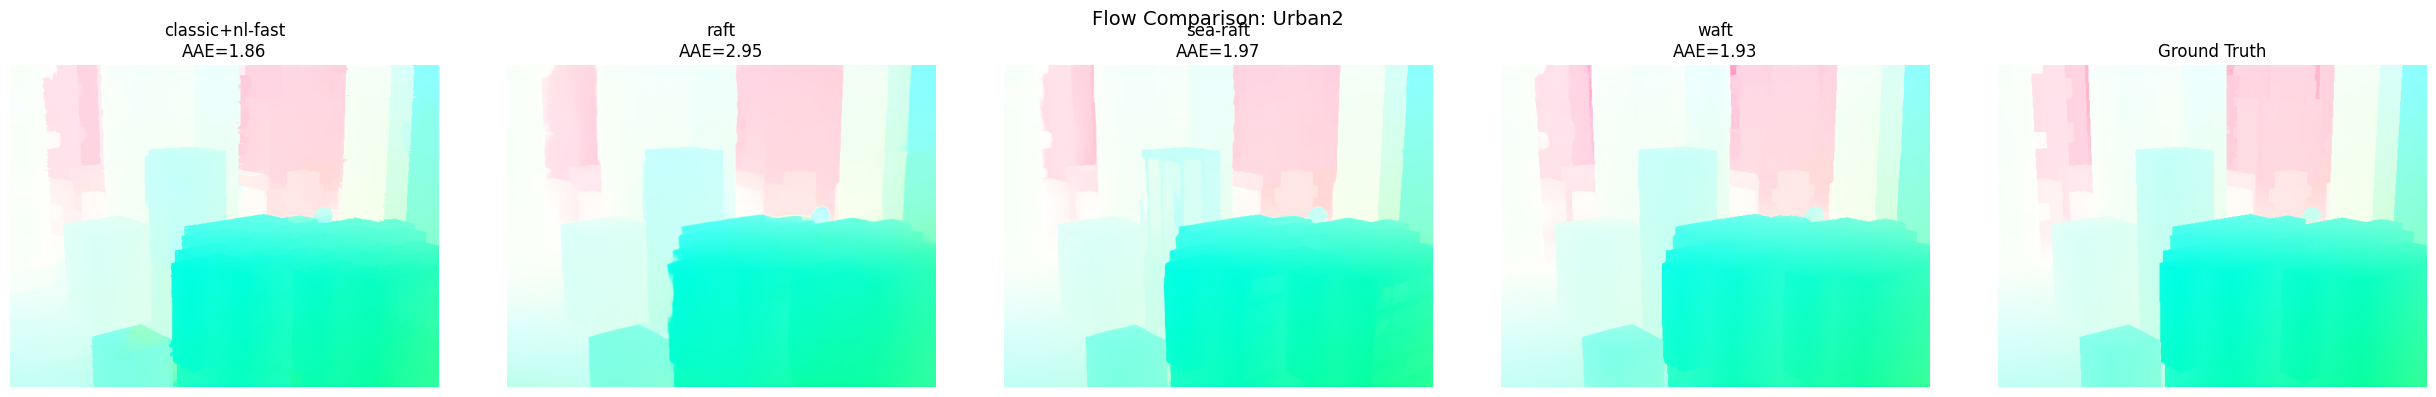

In [9]:
%matplotlib inline

seq = 'Urban2'
gt = read_flo(os.path.join(data_dir, 'other-gt-flow', seq, 'flow10.flo'))

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, m in enumerate(methods):
    color_img = flow_to_color(results[seq][m]['flow'])
    axes[i].imshow(color_img)
    aae = results[seq][m]['aae']
    axes[i].set_title(f'{m}\nAAE={aae:.2f}')
    axes[i].axis('off')

color_gt = flow_to_color(gt)
axes[4].imshow(color_gt)
axes[4].set_title('Ground Truth')
axes[4].axis('off')

plt.suptitle(f'Flow Comparison: {seq}', fontsize=14)
plt.tight_layout()
plt.show()

## Flow Visualization: All Methods on Venus

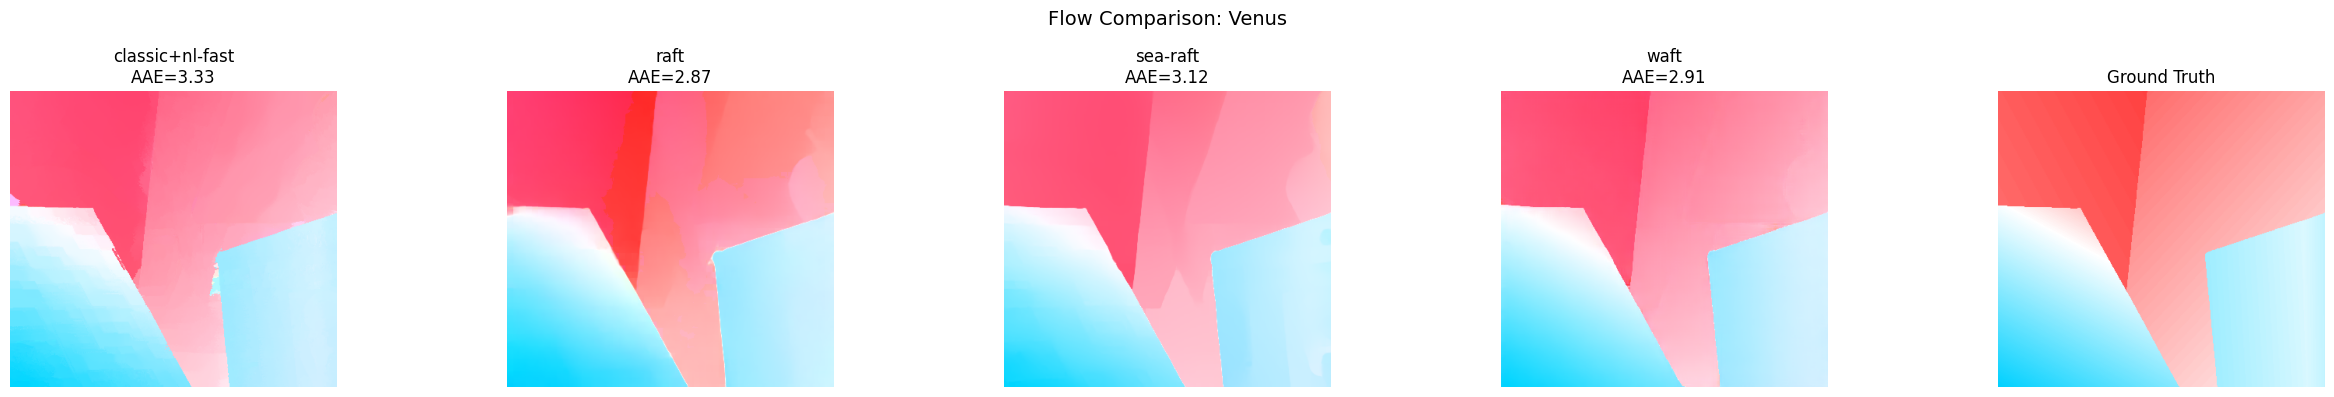

In [8]:
%matplotlib inline

seq = 'Venus'
gt = read_flo(os.path.join(data_dir, 'other-gt-flow', seq, 'flow10.flo'))

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, m in enumerate(methods):
    color_img = flow_to_color(results[seq][m]['flow'])
    axes[i].imshow(color_img)
    aae = results[seq][m]['aae']
    axes[i].set_title(f'{m}\nAAE={aae:.2f}')
    axes[i].axis('off')

color_gt = flow_to_color(gt)
axes[4].imshow(color_gt)
axes[4].set_title('Ground Truth')
axes[4].axis('off')

plt.suptitle(f'Flow Comparison: {seq}', fontsize=14)
plt.tight_layout()
plt.show()